In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('sentiment_analysis.csv')

### ---- Data Cleaning ----


In [3]:
df.sample(10)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
494,2015,10,18,night,"According to , a quarter of families under six...",negative,Twitter
368,2020,12,17,night,had a great time out in the beer garden wit th...,neutral,Instagram
94,2018,9,5,noon,juss came back from Barisal,neutral,Twitter
484,2018,11,7,noon,Hicks are mean!,negative,Instagram
459,2015,8,22,morning,In Arch. Drawing. Checking out MVCC`s CAD degr...,positive,Instagram
73,2017,12,28,noon,Soooo high,neutral,Instagram
444,2020,4,15,morning,Morning tweeple,positive,Instagram
491,2023,1,24,night,No it`s not sad. Should make you proud,negative,Instagram
196,2023,2,25,night,Going to miss my roomie ... We will no longer ...,negative,Facebook
422,2019,6,25,night,a mouth for sure,positive,Facebook


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [5]:
df.isnull().sum()

Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(105)

In [7]:
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()

np.int64(0)

### ---- EDA (Exploratory Data Analysis) ----


In [8]:
df.sample(5)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
19,2019,11,30,noon,I will never fall in love until I found you,positive,Instagram
352,2023,6,17,noon,I saw amazing heeels. But they were too big,neutral,Twitter
457,2022,1,28,noon,this week of mine was not easy! but finally i...,negative,Twitter
404,2017,12,22,night,The little wormy from labyrinth sadly passed a...,neutral,Facebook
358,2023,3,10,noon,this is sooo crazy i have fever..,negative,Twitter


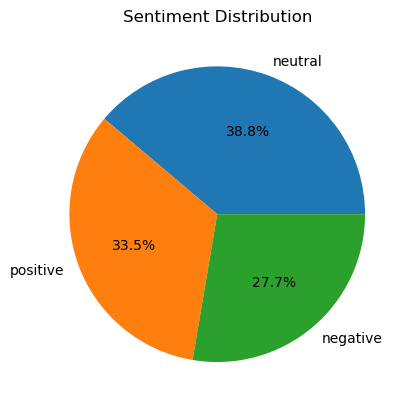

In [9]:
# visualizing a pie chart of sentiments in the dataset
plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index, autopct='%1.1f%%')
plt.title('Sentiment Distribution')
plt.show()

<Axes: xlabel='sentiment', ylabel='count'>

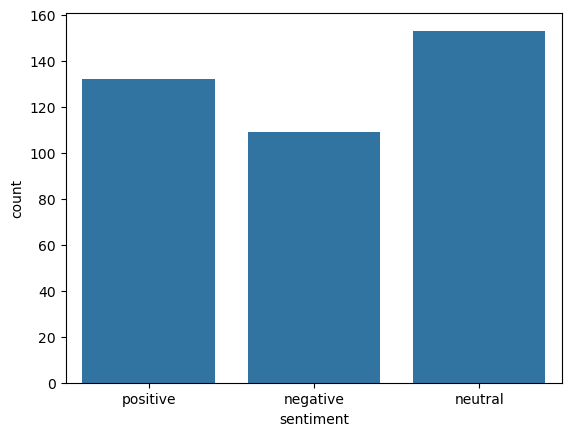

In [10]:
# visualizing the count of each sentiment in the dataset
sns.countplot(x='sentiment', data=df)

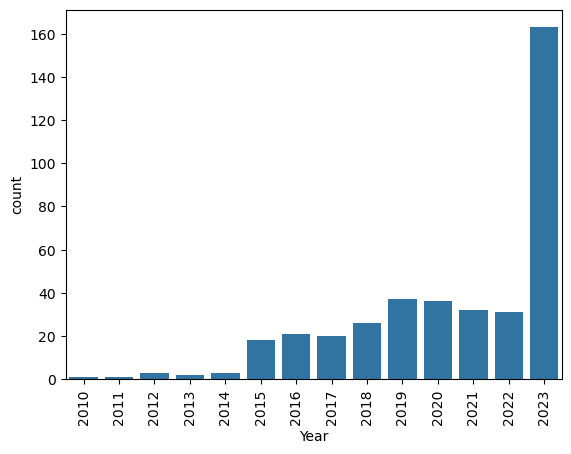

In [11]:
# visualizing the count of each year in the dataset
sns.countplot(x='Year', data=df)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Year', ylabel='sentiment'>

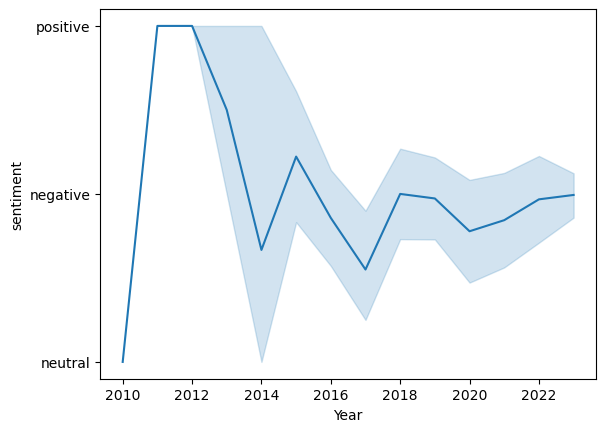

In [12]:
# visualizing the trend of sentiments over the years
sns.lineplot(x='Year', y='sentiment', data=df)

<Axes: xlabel='Month', ylabel='sentiment'>

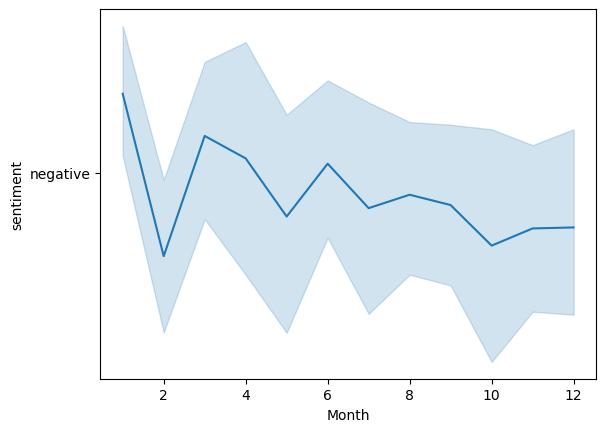

In [13]:
# visualizing the trend of sentiments in a month
sns.lineplot(x='Month', y='sentiment', data=df)

<Axes: xlabel='Day', ylabel='sentiment'>

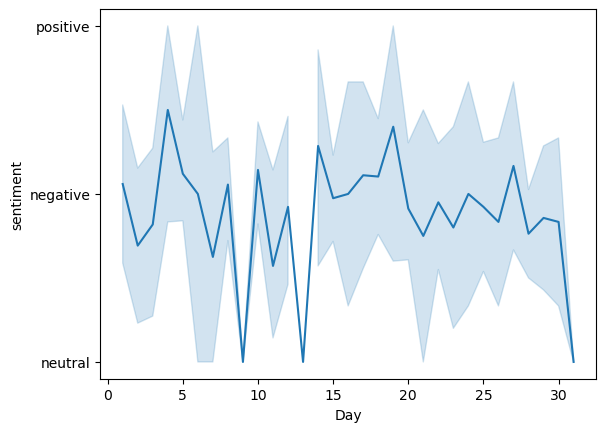

In [14]:
# visualizing the trend of sentiments in a day
sns.lineplot(x='Day', y='sentiment', data=df)

<Axes: xlabel='Time of Tweet', ylabel='count'>

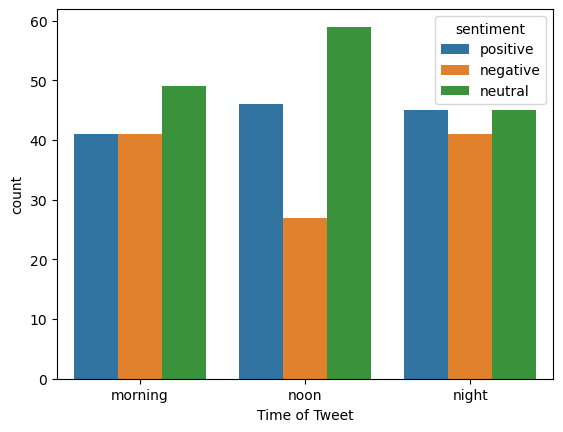

In [15]:
# visualizing the count of sentiments on the basis of time of tweet
sns.countplot(data = df, x='Time of Tweet', hue='sentiment')

<Axes: xlabel='Platform', ylabel='count'>

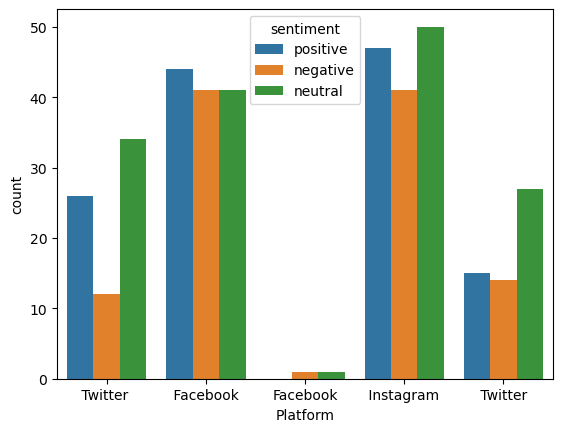

In [16]:
# visualizing the count of sentiments on the basis of platform
sns.countplot(data = df, x='Platform', hue='sentiment')

In [17]:
import nltk

In [18]:
# calculating the number of characters in each tweet and storing it in a new column 'num_characters'
df['num_characters'] = df['text'].apply(len)

In [19]:
# calculating the number of words in each tweet and storing it in a new column 'num_words'
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [20]:
# calculating the number of sentences in each tweet and storing it in a new column 'num_sentences'
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [21]:
df.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,num_characters,num_words,num_sentences
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,37,11,2
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,46,12,1
2,2017,8,18,night,Don't angry me,negative,Facebook,14,4,1
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,84,15,2
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,33,9,1


In [22]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,394.000000,394.000000,394.00000
mean,60.507614,14.010152,1.56599
std,35.259578,8.312589,0.82700
min,4.000000,1.000000,1.00000
25%,33.000000,7.250000,1.00000
50%,53.000000,12.000000,1.00000
75%,84.000000,19.000000,2.00000
max,138.000000,37.000000,7.00000


In [23]:
df[df['sentiment'] == 'positive'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,132.000000,132.000000,132.000000
mean,62.492424,14.083333,1.545455
std,33.535101,7.731211,0.713701
min,8.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,59.000000,13.000000,1.000000
75%,83.000000,18.000000,2.000000
max,138.000000,32.000000,4.000000


In [24]:
df[df['sentiment'] == 'negative'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,109.000000,109.000000,109.000000
mean,62.944954,14.972477,1.623853
std,34.927924,8.370427,0.960218
min,10.000000,2.000000,1.000000
25%,39.000000,9.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,84.000000,20.000000,2.000000
max,137.000000,37.000000,7.000000


In [25]:
df[df['sentiment'] == 'neutral'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,153.000000,153.000000,153.000000
mean,57.058824,13.261438,1.542484
std,36.860911,8.725169,0.819073
min,4.000000,1.000000,1.000000
25%,29.000000,7.000000,1.000000
50%,47.000000,11.000000,1.000000
75%,86.000000,19.000000,2.000000
max,138.000000,36.000000,5.000000


In [26]:
df_H = df.copy()

In [27]:
# mapping the sentiments to numerical values for better analysis
df_H['sentiment'] = df_H['sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})

In [28]:
df_H.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,num_characters,num_words,num_sentences
0,2018,8,18,morning,What a great day!!! Looks like dream.,1,Twitter,37,11,2
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",1,Facebook,46,12,1
2,2017,8,18,night,Don't angry me,-1,Facebook,14,4,1
3,2022,6,8,morning,We attend in the class just for listening teac...,-1,Facebook,84,15,2
4,2022,6,8,noon,"Those who want to go, let them go",-1,Instagram,33,9,1


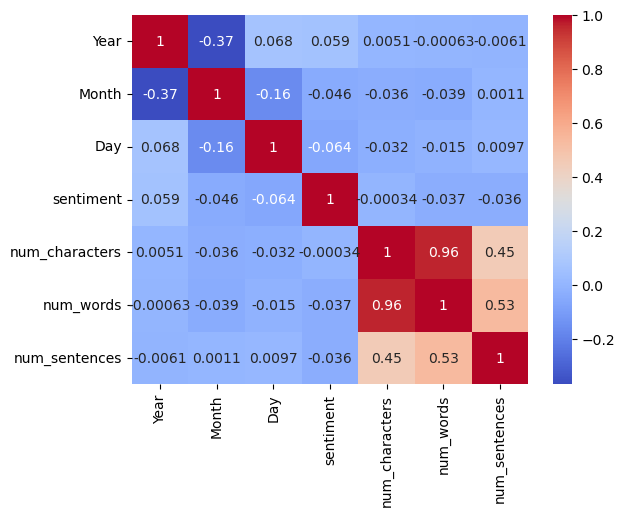

In [29]:
sns.heatmap(df_H.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='num_characters', ylabel='Count'>

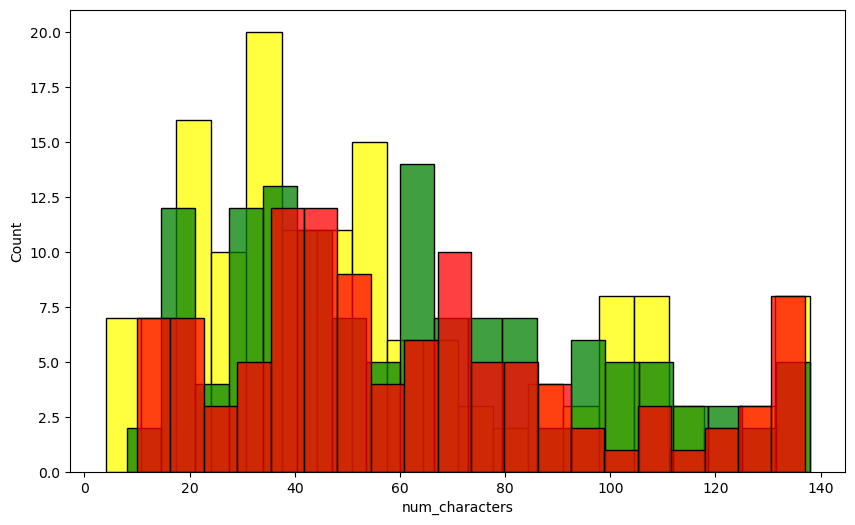

In [30]:
# visualizing the distribution of number of characters in tweets for each sentiment category
plt.figure(figsize=(10, 6))
sns.histplot(df[df['sentiment'] == 'neutral']['num_characters'], color='yellow', bins= 20)
sns.histplot(df[df['sentiment'] == 'positive']['num_characters'],color='green', bins= 20)
sns.histplot(df[df['sentiment'] == 'negative']['num_characters'], color='red', bins= 20)

<Axes: xlabel='num_words', ylabel='Count'>

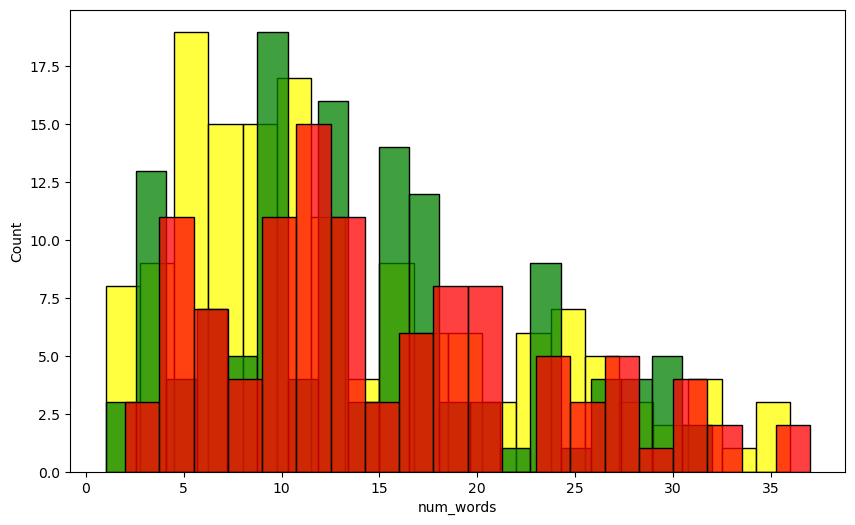

In [31]:
# visualizing the distribution of number of words in tweets for each sentiment category
plt.figure(figsize=(10, 6))
sns.histplot(df[df['sentiment'] == 'neutral']['num_words'], color='yellow', bins=20)
sns.histplot(df[df['sentiment'] == 'positive']['num_words'],color='green', bins=20)
sns.histplot(df[df['sentiment'] == 'negative']['num_words'], color='red', bins=20)

### Data Preprocessing :-

- Convert to lower case
- Tokenize the text
- Remove special characters
- Remove stop words and punctuations
- Stemming


In [32]:
# text preprocessing
import string
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
#nltk.download('stopwords')


def transform_text(text):
    # converting the text to lowercase
    text = text.lower()

    # tokenizing the text (breaking the text into words)
    text = nltk.word_tokenize(text)

    # removing the special characters and only keeping the alphanumeric characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # removing the stop words and punctuation
    text = y[:]
    y.clear()
    for i in text:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    # stemming the words (removing the suffixes from the words)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [33]:
# applying the text transformation function to the 'text' column and storing the transformed text in a new column 'transformed_text'
df['transformed_text'] = df['text'].apply(transform_text)

In [34]:
df.sample(5)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,num_characters,num_words,num_sentences,transformed_text
179,2023,6,7,morning,Went to a party last night. GREAT MINDS THINK ...,positive,Facebook,75,15,2,went parti last night great mind think alik an...
469,2021,8,2,noon,"That`s just weird... :\ Oh, and what was it ...",negative,Instagram,70,20,1,weird oh draw
27,2019,11,18,morning,I'm in the village now and there hardly found ...,negative,Instagram,71,14,1,villag hardli found intern feel gloomi
449,2015,7,12,night,Is heading home from foot surgery and wishing ...,positive,Twitter,94,18,1,head home foot surgeri wish boyfriend come cuddl
178,2023,5,30,night,Smelly? Noooo. I love alex Vixon,neutral,Instagram,33,8,3,smelli noooo love alex vixon


In [35]:
# using wordcloud to visualize the most common words in the text
from wordcloud import WordCloud

In [36]:
wc = WordCloud(width=700, height=400, min_font_size=7, background_color='white')

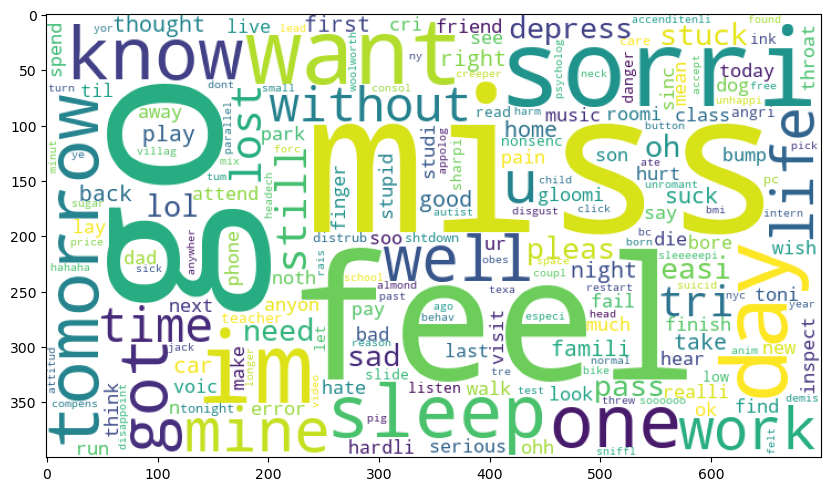

In [37]:
# generating the word cloud for negative messages
negative_wc = wc.generate(df[df['sentiment'] == 'negative']['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(negative_wc)

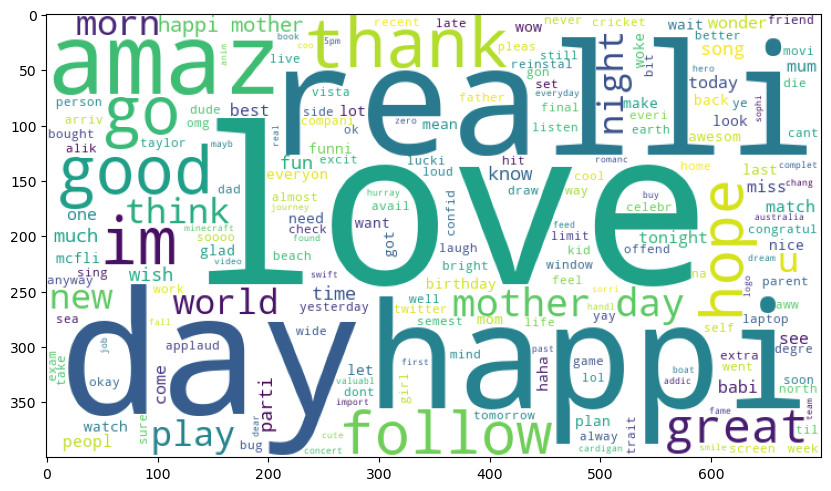

In [38]:
# generating the word cloud for positive messages
positive_wc = wc.generate(df[df['sentiment'] == 'positive']['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(positive_wc)

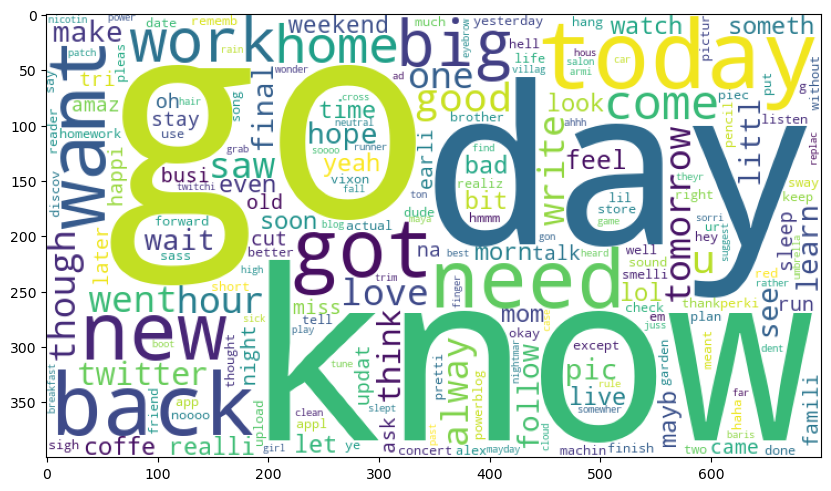

In [39]:
# generating the word cloud for neutral messages
neutral_wc = wc.generate(df[df['sentiment'] == 'neutral']['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(neutral_wc)

In [40]:
# creating a corpus of all the words in the negative tweets so that we can find the most occurring words in the tweets with negative sentiment

neg_corpus = []
for msg in df[df['sentiment'] == 'negative']['transformed_text'].tolist():
    for word in msg.split():
        neg_corpus.append(word)

In [41]:
len(neg_corpus)

682

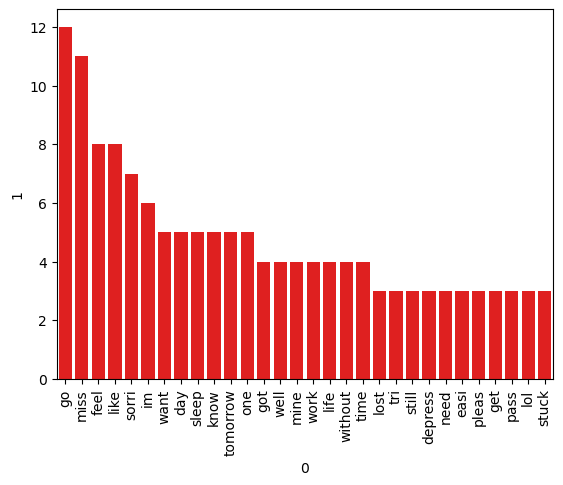

In [42]:
# for negative
from collections import Counter
# 0 - word column, 1 - count of the word
sns.barplot(x = pd.DataFrame(Counter(neg_corpus).most_common(30))[0], y = pd.DataFrame(Counter(neg_corpus).most_common(30))[1], color='red')
plt.xticks(rotation= 'vertical')
plt.show()

In [43]:
# creating a corpus of all the words in the positive tweets so that we can find the most occurring words in the tweets with positive sentiment

pos_corpus = []
for msg in df[df['sentiment'] == 'positive']['transformed_text'].tolist():
    for word in msg.split():
        pos_corpus.append(word)

In [44]:
len(pos_corpus)

877

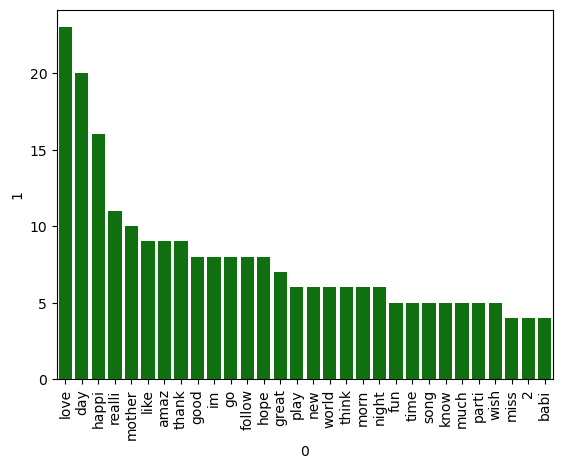

In [45]:
# for positive
from collections import Counter
# 0 - word column, 1 - count of the word
sns.barplot(x = pd.DataFrame(Counter(pos_corpus).most_common(30))[0], y = pd.DataFrame(Counter(pos_corpus).most_common(30))[1], color='green')
plt.xticks(rotation= 'vertical')
plt.show()

In [46]:
# creating a corpus of all the words in the neutral tweets so that we can find the most occurring words in the tweets with neutral sentiment

neutral_corpus = []
for msg in df[df['sentiment'] == 'neutral']['transformed_text'].tolist():
    for word in msg.split():
        neutral_corpus.append(word)

In [47]:
len(neutral_corpus)

890

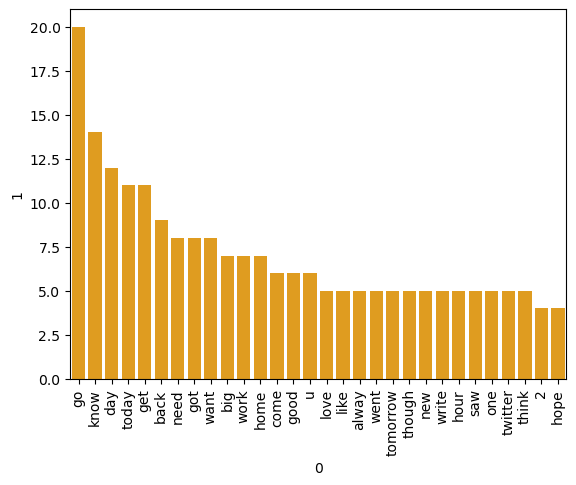

In [48]:
# for neutral
from collections import Counter
# 0 - word column, 1 - count of the word
sns.barplot(x = pd.DataFrame(Counter(neutral_corpus).most_common(30))[0], y = pd.DataFrame(Counter(neutral_corpus).most_common(30))[1], color='orange')
plt.xticks(rotation= 'vertical')
plt.show()

### ---- Model Building ----


In [49]:
dfM = df.copy()
dfM.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,num_characters,num_words,num_sentences,transformed_text
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,37,11,2,great day look like dream
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,46,12,1,feel sorri miss sea beach
2,2017,8,18,night,Don't angry me,negative,Facebook,14,4,1,angri
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,84,15,2,attend class listen teacher read slide nonsenc
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,33,9,1,want go let go


In [50]:
dfM['sentiment'] = dfM['sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})

In [51]:
# appling one hot encoding to the time of tweet , platfrom columns
dfM = pd.get_dummies(dfM, columns=['Time of Tweet', 'Platform'])

In [52]:
dfM.head()

,Year,Month,Day,text,sentiment,num_characters,num_words,num_sentences,transformed_text,Time of Tweet_morning,Time of Tweet_night,Time of Tweet_noon,Platform_ Facebook,Platform_ Instagram,Platform_ Twitter,Platform_ Twitter,Platform_Facebook
0,2018,8,18,What a great day!!! Looks like dream.,1,37,11,2,great day look like dream,True,False,False,False,False,False,True,False
1,2018,8,18,"I feel sorry, I miss you here in the sea beach",1,46,12,1,feel sorri miss sea beach,False,False,True,True,False,False,False,False
2,2017,8,18,Don't angry me,-1,14,4,1,angri,False,True,False,False,False,False,False,True
3,2022,6,8,We attend in the class just for listening teac...,-1,84,15,2,attend class listen teacher read slide nonsenc,True,False,False,True,False,False,False,False
4,2022,6,8,"Those who want to go, let them go",-1,33,9,1,want go let go,False,False,True,False,True,False,False,False


In [53]:
# trasnforming the text data into numerical data using count vectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()

In [54]:
X = cv.fit_transform(dfM['transformed_text']).toarray()

In [55]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(394, 1130))

In [56]:
y = dfM['sentiment'].values

In [57]:
y

array([ 1,  1, -1, -1, -1,  0,  1,  0,  0,  1,  0,  1, -1, -1,  0, -1, -1,
        0,  1,  1,  0,  1,  0, -1,  0,  1, -1, -1,  0,  0,  1,  1, -1,  1,
        0,  1, -1,  0, -1,  1,  0, -1,  0,  0,  1,  0,  0, -1,  1,  0,  0,
       -1, -1,  0,  0, -1, -1,  1,  0,  1,  1,  1,  0,  1,  1,  0,  1,  0,
        0,  1,  1,  0,  1,  0,  1, -1,  0,  0,  0,  0, -1,  0, -1,  1,  1,
        1,  1,  0,  1,  1,  0,  0,  0,  1,  0,  0,  1,  1,  0,  0,  0,  0,
        1,  0, -1, -1,  0,  0,  1,  1,  0, -1,  0,  0, -1,  1,  0, -1,  1,
        0,  0,  1,  1,  1,  1,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
        0,  1, -1, -1,  1, -1,  1,  1,  0, -1,  0, -1,  0, -1,  0,  0,  1,
       -1, -1,  0,  1,  1,  0,  0, -1,  0,  1,  0, -1,  1,  1,  1,  1,  0,
        1,  1,  0,  0,  0,  0,  1,  1,  0, -1,  0,  1, -1,  0,  1,  0,  0,
        0,  0,  1,  0,  1,  1,  1,  0,  1,  0,  0,  0,  1,  1, -1,  0,  0,
        1,  1, -1,  1, -1,  0,  0,  0, -1, -1,  0, -1, -1,  1, -1,  0,  0,
        1, -1,  0, -1,  0

In [58]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [59]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [60]:
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb = GaussianNB()

In [61]:
gnb.fit(X_train, y_train)
y_pred_1 = gnb.predict(X_test)
print("==== Gaussian Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_1), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_1, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_1, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_1, average='weighted'), end ="\n\n")

==== Gaussian Naive Bayes ====
Accuracy: 0.43037974683544306

Confusion Matrix:
[[13  4  3]
 [12  9 15]
 [ 7  4 12]]

Precision: 0.46055472822040205

Recall: 0.43037974683544306

F1 Score: 0.4131836637210413



In [62]:
mnb.fit(X_train, y_train)
y_pred_2 = mnb.predict(X_test)
print("==== Multinomial Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_2), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_2, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_2, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_2, average='weighted'), end ="\n\n")

==== Multinomial Naive Bayes ====
Accuracy: 0.5316455696202531

Confusion Matrix:
[[ 9 10  1]
 [ 1 21 14]
 [ 3  8 12]]

Precision: 0.5500378664935627

Recall: 0.5316455696202531

F1 Score: 0.5330264672036824



In [63]:
bnb.fit(X_train, y_train)
y_pred_3 = bnb.predict(X_test)
print("==== Bernoulli Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_3), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_3, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_3, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_3, average='weighted'), end ="\n\n")

==== Bernoulli Naive Bayes ====
Accuracy: 0.5063291139240507

Confusion Matrix:
[[ 1 18  1]
 [ 0 30  6]
 [ 0 14  9]]

Precision: 0.6374285422621478

Recall: 0.5063291139240507

F1 Score: 0.4374805423630017



In [64]:
# appling logistic regression to the data
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_4 = lr.predict(X_test)
print("==== Logistic Regression ====")
print("Accuracy:", accuracy_score(y_test, y_pred_4), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_4), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_4, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_4, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_4, average='weighted'), end ="\n\n")

==== Logistic Regression ====
Accuracy: 0.5949367088607594

Confusion Matrix:
[[ 8 12  0]
 [ 0 28  8]
 [ 3  9 11]]

Precision: 0.6130718049438902

Recall: 0.5949367088607594

F1 Score: 0.5833904652101755



In [65]:
# appling svm to the data
from sklearn.svm import SVC
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_5 = svm.predict(X_test)
print("==== Support Vector Machine ====")
print("Accuracy:", accuracy_score(y_test, y_pred_5), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_5), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_5, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_5, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_5, average='weighted'), end ="\n\n")

==== Support Vector Machine ====
Accuracy: 0.569620253164557

Confusion Matrix:
[[ 8 11  1]
 [ 2 25  9]
 [ 2  9 12]]

Precision: 0.5807441503644035

Recall: 0.569620253164557

F1 Score: 0.5631504922644163



In [66]:
# applin random forest to the data
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=2)
rf.fit(X_train, y_train)
y_pred_6 = rf.predict(X_test)
print("==== Random Forest ====")
print("Accuracy:", accuracy_score(y_test, y_pred_6), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_6), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_6, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_6, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_6, average='weighted'), end ="\n\n")

==== Random Forest ====
Accuracy: 0.5822784810126582

Confusion Matrix:
[[ 4 16  0]
 [ 1 30  5]
 [ 1 10 12]]

Precision: 0.6184093890720845

Recall: 0.5822784810126582

F1 Score: 0.5497735066254603



In [67]:
# appling gradient boosting to the data
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=2)
gb.fit(X_train, y_train)
y_pred_7 = gb.predict(X_test)
print("==== Gradient Boosting ====")
print("Accuracy:", accuracy_score(y_test, y_pred_7), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_7), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_7, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_7, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_7, average='weighted'), end ="\n\n")

==== Gradient Boosting ====
Accuracy: 0.5443037974683544

Confusion Matrix:
[[ 5 14  1]
 [ 1 30  5]
 [ 2 13  8]]

Precision: 0.5644332349861996

Recall: 0.5443037974683544

F1 Score: 0.5103115131698227



In [68]:
dfXG = df.copy()
dfXG.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,num_characters,num_words,num_sentences,transformed_text
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,37,11,2,great day look like dream
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,46,12,1,feel sorri miss sea beach
2,2017,8,18,night,Don't angry me,negative,Facebook,14,4,1,angri
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,84,15,2,attend class listen teacher read slide nonsenc
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,33,9,1,want go let go


In [69]:
dfXG['sentiment'] = dfXG['sentiment'].map({'positive': 1, 'negative': 2, 'neutral': 0})

In [70]:
X_XG = tfidf.fit_transform(cv.fit_transform(dfXG['transformed_text'])).toarray()

In [71]:
y_XG = dfXG['sentiment'].values


In [72]:
y_XG

array([1, 1, 2, 2, 2, 0, 1, 0, 0, 1, 0, 1, 2, 2, 0, 2, 2, 0, 1, 1, 0, 1,
       0, 2, 0, 1, 2, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 2, 1, 0, 2, 0, 0,
       1, 0, 0, 2, 1, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 0, 0, 0, 0, 2, 0, 2, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 1, 1,
       0, 2, 0, 0, 2, 1, 0, 2, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 2, 2, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2, 0, 0, 1, 2,
       2, 0, 1, 1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 2, 0, 0, 1, 1, 2, 1, 2, 0, 0, 0, 2, 2, 0, 2, 2, 1, 2, 0,
       0, 1, 2, 0, 2, 0, 0, 1, 0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 1,
       1, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       2, 0, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 0, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 0, 0, 2, 0, 0,

In [73]:
X_train_XG, X_test_XG, y_train_XG, y_test_XG = train_test_split(X_XG, y_XG, test_size=0.2, random_state=2)

In [74]:
# applying XGBoost to the data
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=2)
xgb.fit(X_train_XG, y_train_XG)
y_pred_8 = xgb.predict(X_test_XG)
print("==== XGBoost ====")
print("Accuracy:", accuracy_score(y_test_XG, y_pred_8), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_XG, y_pred_8), end ="\n\n")
print("Precision:", precision_score(y_test_XG, y_pred_8, average='weighted'), end ="\n\n")
print("Recall:", recall_score(y_test_XG, y_pred_8, average='weighted'), end ="\n\n")
print("F1 Score:", f1_score(y_test_XG, y_pred_8, average='weighted'), end ="\n\n")


==== XGBoost ====
Accuracy: 0.4810126582278481

Confusion Matrix:
[[24  8  4]
 [ 8  8  7]
 [13  1  6]]

Precision: 0.4693968726731199

Recall: 0.4810126582278481

F1 Score: 0.4686053141749344

